# Imports

In [124]:
import pandas as pd
import dill
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.dummy import DummyClassifier
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import GridSearchCV

# Ga_Sessions

## Data Preparation

### Data loading

In [12]:
df = pd.read_csv('data/ga_sessions.csv')
df.head()

C:\Users\Максим\AppData\Local\Temp\ipykernel_10016\2960945628.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/ga_sessions.csv')


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [13]:
df.shape

(1860042, 18)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


In [15]:
df.describe()

,visit_number
count,1.860042e+06
mean,2.712804e+00
std,1.182907e+01
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,2.000000e+00
max,5.640000e+02


In [16]:
df.visit_number.max()

564

In [17]:
df.isnull().sum()

session_id                        0
client_id                         0
visit_date                        0
visit_time                        0
visit_number                      0
utm_source                       97
utm_medium                        0
utm_campaign                 219603
utm_adcontent                335615
utm_keyword                 1082061
device_category                   0
device_os                   1070138
device_brand                 367178
device_model                1843704
device_screen_resolution          0
device_browser                    0
geo_country                       0
geo_city                          0
dtype: int64

# Ga_hits

## Data Preparation

### Data Load

In [18]:
df_hits_sample = pd.read_csv('data/ga_hits-003.csv', nrows=5)
df_hits_sample.columns.tolist()

['session_id',
 'hit_date',
 'hit_time',
 'hit_number',
 'hit_type',
 'hit_referer',
 'hit_page_path',
 'event_category',
 'event_action',
 'event_label',
 'event_value']

In [19]:
df_hits_sample = pd.read_csv('data/ga_hits-003.csv', nrows=10000)
df_hits_sample['event_action'].value_counts().head(20)

event_action
view_card                             2802
view_new_card                         2192
sub_landing                           1814
sub_view_cars_click                    609
go_to_car_card                         351
showed_number_ads                      237
search_form_search_btn                 187
search_form_region                     167
pagination_click                       161
photos_all                             147
sap_search_form_cost_to                141
view_more_click                        107
search_form_mark_select                 97
search_form_model_select                92
search_form_search_car_type_select      58
sap_search_form_cost_from               54
photos                                  54
quiz_show                               52
sub_header_link_click                   37
search_kpp                              35
Name: count, dtype: int64

In [20]:
target_actions = [
    'sub_car_claim_click',
    'sub_car_claim_submit_click', 
    'sub_open_dialog_click',
    'sub_custom_question_submit_click',
    'sub_call_number_click',
    'sub_callback_submit_click',
    'sub_submit_success',
    'sub_car_request_submit_click'
]

chunks = []
for chunk in pd.read_csv('data/ga_hits-003.csv', chunksize=100_000):
    filtered = chunk[chunk['event_action'].isin(target_actions)][['session_id', 'event_action']]
    chunks.append(filtered)

df_hits = pd.concat(chunks, ignore_index=True)

In [21]:
df_hits['target'] = 1

target = df_hits.groupby('session_id')['target'].max().reset_index()

In [22]:
target.nunique()

session_id    50760
target            1
dtype: int64

# Merge

## Data Preparation

In [23]:
df = df.merge(target, on='session_id', how='left')
df['target'] = df['target'].fillna(0).astype(int)

In [24]:
df.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,target
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0


In [25]:
df.target.unique()

array([0, 1])

### Data split

In [26]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X.select_dtypes('object').columns.tolist()
num_cols = X.select_dtypes('number').columns.tolist()

### Fucntions

In [27]:
def fit_artifacts(df):
    df_copy = df.copy()
    artifacts = {}

    # 1. os_map
    artifacts['os_map'] = (
            df_copy[df_copy['device_os'].notna()]
            .groupby(['device_category', 'device_brand'])['device_os']
            .agg(lambda x: x.mode()[0])
        )

    # 2. first_visit_map
    artifacts['first_visit_map'] = df_copy.groupby('client_id')['visit_date'].min()

    # 3. screen_mode_map
    df_copy['device_screen_resolution'] = df_copy['device_screen_resolution'].replace('(not set)', '0x0')
    df_copy['screen_width'] = df_copy['device_screen_resolution'].str.split('x').str[0].astype(int).replace(0, np.nan)
    df_copy['screen_height'] = df_copy['device_screen_resolution'].str.split('x').str[1].astype(int).replace(0, np.nan)
    artifacts['screen_mode_map'] = {}
    for col in ['screen_width', 'screen_height']:
            artifacts['screen_mode_map'][col] = df_copy.groupby('device_category')[col].agg(lambda x: x.mode()[0])

    # 4. boundaries
    artifacts['boundaries'] = {}
    for col in ['visit_number', 'screen_width', 'screen_height']:
            q25 = df_copy[col].quantile(0.25)
            q75 = df_copy[col].quantile(0.75)
            iqr = q75 - q25
            artifacts['boundaries'][col] = (q25 - 1.5 * iqr, q75 + 1.5 * iqr)

    # 5. top_categories
    artifacts['top_categories'] = {}
    for col in ['utm_source', 'utm_campaign', 'utm_keyword', 
                    'utm_adcontent', 'utm_medium', 'device_brand', 'device_browser']:
            artifacts['top_categories'][col] = df_copy[col].value_counts().head(20).index.tolist()

    return artifacts

In [28]:
def transform(df, artifacts):
    df_copy = df.copy()
    
    # 1. Типизация
    df_copy['visit_date'] = pd.to_datetime(df_copy['visit_date'])
    df_copy['visit_time'] = pd.to_datetime(df_copy['visit_time'], format='%H:%M:%S').dt.time

    
    # 2. Заполнение пропусков (utm, device_brand, device_os через os_map)
    df_copy['utm_keyword'] = df_copy['utm_keyword'].fillna('not_set')
    df_copy['utm_campaign'] = df_copy['utm_campaign'].fillna('not_set')
    df_copy['utm_adcontent'] = df_copy['utm_adcontent'].fillna('not_set')
    df_copy['device_brand'] = df_copy['device_brand'].fillna('not_set')
    df_copy['utm_source'] = df_copy['utm_source'].fillna('not_set')

    os_map = artifacts['os_map']
    df_copy['device_os'] = df_copy.apply(
        lambda row: os_map.get((row['device_category'], row['device_brand']), 'not_set')
        if pd.isna(row['device_os']) else row['device_os'], axis=1
    )

    
    # 3. Удаление device_model
    df_copy = df_copy.drop(columns=['device_model'])

    
    # 4. Feature engineering
    df_copy['visit_month'] = df_copy['visit_date'].dt.month
    df_copy['visit_day'] = df_copy['visit_date'].dt.day
    df_copy['visit_dayofweek'] = df_copy['visit_date'].dt.dayofweek
    df_copy['visit_hour'] = pd.to_datetime(df_copy['visit_time'], format='%H:%M:%S').dt.hour

    df_copy['is_russia'] = (df_copy['geo_country'] == 'Russia').astype(int)

    first_visit_map = artifacts['first_visit_map']
    df_copy['is_new_client'] = df_copy['client_id'].map(
        lambda x: 0 if x in first_visit_map.index else 1
    )

    df_copy['city_group'] = df_copy['geo_city'].apply(
        lambda x: 'moscow' if 'Moscow' in str(x)
        else 'spb' if 'Saint Petersburg' in str(x)
        else 'other'
    )

    organic = ['organic', 'referral', '(none)']
    df_copy['is_organic'] = df_copy['utm_medium'].isin(organic).astype(int)

    social_sources = ['QxAxdyPLuQMEcrdZWdWb', 'MvfHsxITijuriZxsqZqt',
                      'ISrKoXQCxqqYvAZICvjs', 'IZEXUFLARCUMynmHNBGo',
                      'PlbkrSYoHuZBWfYjYnfw', 'gVRrcxiDQubJiljoTbGm']
    df_copy['is_social'] = df_copy['utm_source'].isin(social_sources).astype(int)

    df_copy = df_copy.drop(columns=['session_id', 'client_id', 'visit_date', 'visit_time', 'geo_country', 'geo_city'])

    
    # 5. screen_resolution → screen_width, screen_height + screen_mode_map
    df_copy['device_screen_resolution'] = df_copy['device_screen_resolution'].replace('(not set)', '0x0')
    df_copy['screen_width'] = df_copy['device_screen_resolution'].str.split('x').str[0].astype(int)
    df_copy['screen_height'] = df_copy['device_screen_resolution'].str.split('x').str[1].astype(int)
    df_copy = df_copy.drop(columns=['device_screen_resolution'])

    for col in ['screen_width', 'screen_height']:
        df_copy[col] = df_copy[col].replace(0, None)
        mode_map = artifacts['screen_mode_map'][col]
        df_copy[col] = df_copy.apply(
            lambda row: mode_map[row['device_category']]
            if pd.isna(row[col]) else row[col], axis=1
        )

        
    # 6. Выбросы через boundaries
    boundaries = artifacts['boundaries']

    for col, (lower_bound, upper_bound) in boundaries.items():
        df_copy[col] = df_copy[col].clip(lower=lower_bound, upper=upper_bound)

        
    # 7. Топ категории
    top_categories = artifacts['top_categories']

    for col, top_values in top_categories.items():
        df_copy[col] = df_copy[col].where(
            df_copy[col].isin(top_values), other='other'
        )
    
    return df_copy

In [29]:
artifacts = fit_artifacts(X_train)

### Data Types

In [84]:
X_train['visit_date'] = pd.to_datetime(X_train['visit_date'])
X_train['visit_time'] = pd.to_datetime(X_train['visit_time'], format='%H:%M:%S').dt.time

### Fill null

In [30]:
(X_train.isnull().sum() / len(df) * 100).round(1)

session_id                   0.0
client_id                    0.0
visit_date                   0.0
visit_time                   0.0
visit_number                 0.0
utm_source                   0.0
utm_medium                   0.0
utm_campaign                 9.4
utm_adcontent               14.4
utm_keyword                 46.5
device_category              0.0
device_os                   46.0
device_brand                15.8
device_model                79.3
device_screen_resolution     0.0
device_browser               0.0
geo_country                  0.0
geo_city                     0.0
dtype: float64

#### UTM Block

In [31]:
X_train[X_train.utm_source.isnull()]

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
1197087,6101018397274780643.1638962185.1638962185,1420504040.1638904803,2021-12-08,14:16:25,3,NaN,(not set),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x780,Chrome,Russia,Moscow
351007,2327199327706508246.1640966589.1640966589,541843317.1635347414,2021-12-31,19:03:09,8,NaN,promo_sbol,cccMlyVfjXspfaCSrMsO,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Realme,NaN,360x800,Chrome,Russia,Moscow
294668,2076063222578022290.1637741232.1637741232,483371136.1627654034,2021-11-24,11:07:12,188,NaN,CPM,IKQsApKuPmZqqmhieEgf,NaN,vuriSCpYEnMEbLACpaMZ,desktop,Macintosh,NaN,NaN,1920x1080,Chrome,Russia,Moscow
1326832,6675031872911888372.1638945614.1638945614,1554151967.163282,2021-12-08,09:40:14,82,NaN,CPM,IKQsApKuPmZqqmhieEgf,NaN,vuriSCpYEnMEbLACpaMZ,desktop,Macintosh,NaN,NaN,1792x1120,Chrome,Russia,Moscow
1326793,6675031872911888372.1635154650.1635154650,1554151967.163282,2021-10-25,12:37:30,17,NaN,CPM,IKQsApKuPmZqqmhieEgf,NaN,vuriSCpYEnMEbLACpaMZ,desktop,Macintosh,NaN,NaN,1792x1120,Chrome,Russia,Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1398294,6998726425393932505.1639959088.1639959088,1629517978.163988,2021-12-20,03:11:28,4,NaN,web_polka,cccMlyVfjXspfaCSrMsO,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,NaN,393x873,Chrome,Russia,Moscow
1629118,8025307339522195714.1638469056.1638469056,1868537473.163671,2021-12-02,21:17:36,11,NaN,(not set),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x780,Chrome,Russia,Krasnodar
1326813,6675031872911888372.1637260751.1637260751,1554151967.163282,2021-11-18,21:39:11,49,NaN,CPM,IKQsApKuPmZqqmhieEgf,NaN,vuriSCpYEnMEbLACpaMZ,desktop,Macintosh,NaN,NaN,1792x1120,Chrome,Russia,Moscow
1629110,8025307339522195714.1637497362.1637497362,1868537473.163671,2021-11-21,15:22:42,3,NaN,(not set),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x780,Chrome,Russia,Sochi


In [32]:
X_train[X_train.utm_campaign == 'LTuZkdKfxRGVceoWkVyg']

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
1795167,8764064683919227725.1636645708.1636645708,2040542821.163664,2021-11-11,18:48:28,1,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,UKNBOHebRIIsQRsjNKay,desktop,Windows,NaN,NaN,1536x864,Opera,Russia,Kirov
1238270,6286015961692457156.1629309173.1629309173,1463577142.162931,2021-08-18,20:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Samsung,NaN,412x846,Android Webview,Russia,(not set)
1010267,5265226858196995121.1621986355.1621986355,1225906158.162199,2021-05-26,02:00:00,1,FTAuYVNoYYxgvKMpKSLW,referral,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,desktop,NaN,NaN,NaN,1600x900,Firefox,Russia,Moscow
522151,3089741372048566779.1623747066.1623747066,719386472.162375,2021-06-15,11:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Apple,NaN,414x896,Safari (in-app),Russia,Moscow
717249,3962709353457367435.1626454413.1626454528,922640169.162645,2021-07-16,19:00:00,1,bByPQxmDaMXgpHeypKSM,referral,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Apple,NaN,375x667,Safari,Russia,Ryazan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689309,3836922470161144173.1635254108.1635254108,893353128.162184,2021-10-26,16:15:08,16,YclHumxPxSxgzHfvCaeF,referral,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,desktop,Windows,NaN,NaN,1920x1080,Edge,Russia,Sochi
820582,4421065780809639772.1640703837.1640703837,1029359591.16407,2021-12-28,18:03:57,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,desktop,Windows,NaN,NaN,1280x720,Chrome,Russia,Moscow
214022,1713339164112355937.1622049376.1622049376,398917860.1622049377,2021-05-26,20:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Apple,NaN,414x896,Safari,Russia,Moscow
781508,4248601815699796143.1625141423.1625141423,989204695.162514,2021-07-01,15:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Apple,NaN,414x736,Safari (in-app),Russia,Saint Petersburg


Делаю вывод что utm_source, utm_medium, utm_campaign, utm_adcontent, utm_keyowrd имеют связь и их можно заполнить с помощью этой связи

In [33]:
X_train[['utm_source', 'utm_medium', 'utm_campaign', 'utm_keyword']].dropna().head(20)

,utm_source,utm_medium,utm_campaign,utm_keyword
1795167,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,UKNBOHebRIIsQRsjNKay
1450600,fgymSoTvjKPEgaIJqsiH,cpm,FTjNLDyTrXaWYgZymFkV,ObIWuFTMgFPUHNiFoOwb
1472533,vFcAhRxLfOWKhvxjELkx,organic,okTXSMadDkjvntEHzIjp,aXQzDWsJuGXeBXexNHjc
290942,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo
1656524,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo
1659563,ZpYIoDJMcFzVoPFsHGJL,banner,TmThBvoCcwkCZZUWACYq,puhZPIYqKXeFPaUviSjo
1583061,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo
315591,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo
893319,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo
1160404,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,pHqgLcdBQPSLcrTpLkdr


In [34]:
X_train[X_train['utm_keyword'].isnull()][['utm_source', 'utm_medium']].value_counts().head(10)

utm_source            utm_medium
fDLlAcSmythWSCVMvqvL  (none)        185731
ZpYIoDJMcFzVoPFsHGJL  banner        183048
kjsLglQLzykiRbcDiGcD  cpc           126922
MvfHsxITijuriZxsqZqt  cpm            61912
bByPQxmDaMXgpHeypKSM  referral       60823
BHcvLfOaCWvWTykYqHVe  cpc            59303
QxAxdyPLuQMEcrdZWdWb  cpc            21483
kjsLglQLzykiRbcDiGcD  organic        19566
aXQzDWsJuGXeBXexNHjc  referral       19427
RmEBuqrriAfAVsLQQmhk  cpc            17175
Name: count, dtype: int64

Заполняю utm_keyword значением not set т.к. имеет смысл в источниках трафика отсутствие ключевых слов как факт

In [35]:
X_train['utm_keyword'] = X_train['utm_keyword'].fillna('not_set')

In [36]:
X_train[X_train['utm_campaign'].isnull()][['utm_source', 'utm_medium']].value_counts().head(10)

utm_source            utm_medium
BHcvLfOaCWvWTykYqHVe  cpc           88168
kjsLglQLzykiRbcDiGcD  cpc           69456
QxAxdyPLuQMEcrdZWdWb  cpc            6190
SzZERoLMmrEUEhDaYcyN  cpc            5459
bByPQxmDaMXgpHeypKSM  referral       4500
ISrKoXQCxqqYvAZICvjs  smm            1348
iNFgfQPqHPBuvGCYtrQE  smm             194
QxAxdyPLuQMEcrdZWdWb  smm              60
GmILPdZyuAVJCPsUBHeN  cpc              21
jaSOmLICuBzCFqHfBdRg  email            15
Name: count, dtype: int64

In [37]:
X_train['utm_campaign'] = X_train['utm_campaign'].fillna('not_set')

In [38]:
X_train['utm_adcontent'] = X_train['utm_adcontent'].fillna('not_set')

Так как все показатели зашифрованы было принято решение заполнить их значением not_set т.к. предположительно в большинстве случаев это так и должно быть

In [39]:
(X_train.isnull().sum() / len(X_train) * 100).round(1)

session_id                   0.0
client_id                    0.0
visit_date                   0.0
visit_time                   0.0
visit_number                 0.0
utm_source                   0.0
utm_medium                   0.0
utm_campaign                 0.0
utm_adcontent                0.0
utm_keyword                  0.0
device_category              0.0
device_os                   57.5
device_brand                19.7
device_model                99.1
device_screen_resolution     0.0
device_browser               0.0
geo_country                  0.0
geo_city                     0.0
dtype: float64

#### Device Block

In [40]:
X_train[X_train['device_os'].isnull()]['device_category'].value_counts()

device_category
mobile     648503
desktop    198227
tablet       9232
Name: count, dtype: int64

In [41]:
X_train[X_train['device_category'] == 'mobile']['device_os'].value_counts().head(10)

device_os
Android          367370
iOS              164471
Linux                37
BlackBerry           20
(not set)            15
Windows              11
Macintosh             5
Tizen                 5
Windows Phone         4
Samsung               4
Name: count, dtype: int64

In [42]:
X_train.groupby('device_category')['device_os'].apply(lambda x: x.isnull().mean() * 100).round(1)

device_category
desktop    67.7
mobile     54.9
tablet     63.2
Name: device_os, dtype: float64

Создаю словарь где в ключе будет device_category+device_brand а в значении device_os

In [43]:
os_map = X_train[X_train['device_os'].notna()].groupby(['device_category', 'device_brand'])['device_os'].agg(lambda x: x.mode()[0])

In [44]:
X_train['device_os'] = X_train.apply(
    lambda row: os_map.get((row['device_category'], row['device_brand']), 'not_set') 
    if pd.isna(row['device_os']) else row['device_os'], axis=1
)

In [45]:
X_train['device_os'].isnull().sum()

np.int64(0)

In [46]:
X_train['device_os'].nunique()

14

In [47]:
(X_train.isnull().sum() / len(X_train) * 100).round(1)

session_id                   0.0
client_id                    0.0
visit_date                   0.0
visit_time                   0.0
visit_number                 0.0
utm_source                   0.0
utm_medium                   0.0
utm_campaign                 0.0
utm_adcontent                0.0
utm_keyword                  0.0
device_category              0.0
device_os                    0.0
device_brand                19.7
device_model                99.1
device_screen_resolution     0.0
device_browser               0.0
geo_country                  0.0
geo_city                     0.0
dtype: float64

Планриую заполнить Device brand модой для каждой device_category, а колонку device_model удалить

In [48]:
X_train.groupby('device_category')['device_brand'].nunique()

device_category
desktop     14
mobile     165
tablet      67
Name: device_brand, dtype: int64

In [49]:
X_train.groupby('device_category')['device_brand'].apply(
    lambda x: f"{x.mode()[0]} ({x.value_counts().iloc[0]/len(x)*100:.1f}%)"
)

device_category
desktop     Apple (0.0%)
mobile     Apple (37.0%)
tablet     Apple (34.1%)
Name: device_brand, dtype: object

In [50]:
X_train[(X_train['device_brand'].isnull()) & (X_train['device_category'] == 'mobile')]

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
115356,1269620015390850818.1631033517.1631033517,295606445.1629028098,2021-09-07,19:00:00,10,kjsLglQLzykiRbcDiGcD,cpc,DsqwamlMwRgMTyspCjFR,JNHcPlZPxEMWDnRiyoBf,not_set,mobile,not_set,NaN,NaN,393x851,Chrome,Russia,Moscow
1489510,7403463643490073349.1640069927.1640069927,1723753205.163989,2021-12-21,09:58:47,2,kjsLglQLzykiRbcDiGcD,cpc,UjApcvnaHtkydRkrLYuv,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Linux,NaN,NaN,393x786,Chrome,Russia,Saint Petersburg
98860,1195675534838902431.1622322849.1622322849,278389904.1622322847,2021-05-30,00:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,not_set,XKsYZiUFcdkUXQpoLKyS,not_set,mobile,not_set,NaN,NaN,360x800,Chrome,Russia,Saint Petersburg
744257,4083951036064253630.1622449092.1622449092,950868948.162233,2021-05-31,11:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,not_set,XKsYZiUFcdkUXQpoLKyS,not_set,mobile,not_set,NaN,NaN,343x724,Chrome,Russia,Moscow
638499,3609293545698777461.1635539319.1635539319,840354139.163554,2021-10-29,23:28:39,1,kjsLglQLzykiRbcDiGcD,cpc,xhbLYKykcxmylecTsBop,JNHcPlZPxEMWDnRiyoBf,tzIeQUUHahhBuEkJqDVp,mobile,Linux,NaN,NaN,1600x1200,Chrome,India,Gurgaon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713677,3945580422587720133.1628676105.1628676105,918652029.162868,2021-08-11,13:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,RoDitORHdzGfGhNCyEMy,not_set,not_set,mobile,not_set,NaN,NaN,1280x720,Edge,Russia,Moscow
1501363,7457462583661740334.1626128700.1626128700,1736325813.162613,2021-07-13,01:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,DnEUulZAecfGPvdtZBYS,JNHcPlZPxEMWDnRiyoBf,not_set,mobile,not_set,NaN,NaN,393x699,Chrome,Russia,Moscow
214819,1716916824633301816.1630067519.1630067519,399750849.1630067512,2021-08-27,15:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,not_set,not_set,not_set,mobile,not_set,NaN,NaN,360x800,Chrome,Russia,Moscow
1321211,6649947288207716740.1622241664.1622241664,1548311507.162224,2021-05-29,01:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,not_set,aYAcKhelKzYpXrRYknSP,not_set,mobile,not_set,NaN,NaN,792x384,Chrome,Russia,Saint Petersburg


Т.к. нет доминантной моды принимаю решение заполнить device_brand значением not_set

In [51]:
X_train['device_brand'] = X_train['device_brand'].fillna('not_set')
X_train = X_train.drop(columns=['device_model'])

In [52]:
X_train.isnull().sum()

session_id                   0
client_id                    0
visit_date                   0
visit_time                   0
visit_number                 0
utm_source                  81
utm_medium                   0
utm_campaign                 0
utm_adcontent                0
utm_keyword                  0
device_category              0
device_os                    0
device_brand                 0
device_screen_resolution     0
device_browser               0
geo_country                  0
geo_city                     0
dtype: int64

In [53]:
X_train['utm_source'] = X_train.utm_source.fillna('not_set')

In [54]:
X_train.isnull().sum().sum()

np.int64(0)

### Dublicates

In [55]:
X_train.duplicated().sum()

np.int64(0)

In [56]:
X_train['session_id'].duplicated().sum()

np.int64(0)

Дубликатов не обнаружено

### outliers

In [57]:
X_train.select_dtypes(include='number').columns

Index(['visit_number'], dtype='object')

In [58]:
X_train.visit_number.describe()

count    1.488033e+06
mean     2.718396e+00
std      1.187349e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      5.640000e+02
Name: visit_number, dtype: float64

In [59]:
X_train['visit_number'].quantile([0.95, 0.99, 0.999])

0.950      6.0
0.990     32.0
0.999    190.0
Name: visit_number, dtype: float64

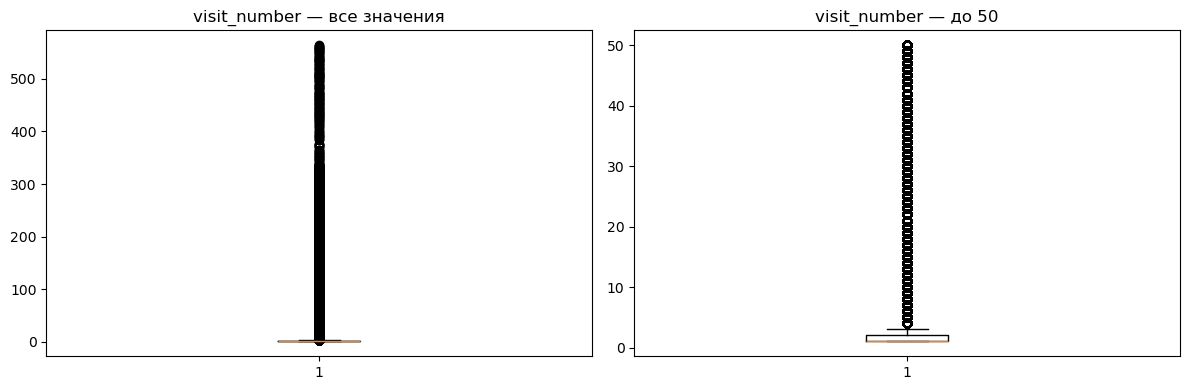

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# До обрезки
axes[0].boxplot(X_train['visit_number'])
axes[0].set_title('visit_number — все значения')

# Посмотрим без экстремальных выбросов
axes[1].boxplot(X_train[X_train['visit_number'] <= 50]['visit_number'])
axes[1].set_title('visit_number — до 50')

plt.tight_layout()
plt.show()

In [61]:
q_25_vn = X_train.visit_number.quantile(0.25)
q_75_vn = X_train.visit_number.quantile(0.75)
iqr = q_75_vn - q_25_vn
boundaries = (q_25_vn - 1.5 * iqr, q_75_vn + 1.5 * iqr)
X_train.visit_number = X_train.visit_number.clip(upper=boundaries[1], lower=boundaries[0])

In [62]:
X_train.visit_number.describe()

count    1.488033e+06
mean     1.438156e+00
std      8.184289e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      3.500000e+00
Name: visit_number, dtype: float64

In [63]:
X_train['device_screen_resolution'] = X_train['device_screen_resolution'].replace('(not set)', '0x0')

X_train['screen_width'] = X_train['device_screen_resolution'].str.split('x').str[0].astype(int)
X_train['screen_height'] = X_train['device_screen_resolution'].str.split('x').str[1].astype(int)
X_train = X_train.drop(columns=['device_screen_resolution'])

In [64]:
# Заменяем 0 на NaN чтобы не учитывать при расчёте моды
X_train['screen_width'] = X_train['screen_width'].replace(0, np.nan)
X_train['screen_height'] = X_train['screen_height'].replace(0, np.nan)


# Заполняем модой по device_category
for col in ['screen_width', 'screen_height']:
    mode_map = X_train.groupby('device_category')[col].agg(lambda x: x.mode()[0])
    df[col] = X_train.apply(
        lambda row: mode_map[row['device_category']] 
        if pd.isna(row[col]) else row[col], axis=1
    )

In [65]:
screen_mode_map = {}
for col in ['screen_width', 'screen_height']:
    screen_mode_map[col] = X_train.groupby('device_category')[col].agg(lambda x: x.mode()[0])

In [66]:
X_train['screen_width'].describe()

count    1.488020e+06
mean     6.563684e+02
std      5.528768e+02
min      1.800000e+02
25%      3.600000e+02
50%      3.930000e+02
75%      4.280000e+02
max      5.924000e+03
Name: screen_width, dtype: float64

In [67]:
X_train['screen_height'].describe()

count    1.488020e+06
mean     8.408757e+02
std      1.949683e+02
min      2.560000e+02
25%      7.600000e+02
50%      8.440000e+02
75%      8.960000e+02
max      2.000000e+04
Name: screen_height, dtype: float64

In [68]:
q_25_sw = X_train['screen_width'].quantile(0.25)
q_75_sw = X_train['screen_width'].quantile(0.75)
q_25_sh = X_train['screen_height'].quantile(0.25)
q_75_sh = X_train['screen_height'].quantile(0.75)



for col in ['screen_width', 'screen_height']:
    q_25 = X_train[col].quantile(0.25)
    q_75 = X_train[col].quantile(0.75)
    iqr = q_75 - q_25
    X_train[col] = X_train[col].clip(lower=q_25 - 1.5*iqr, upper=q_75 + 1.5*iqr)

In [69]:
X_train['screen_width'].describe()

count    1.488020e+06
mean     4.172607e+02
std      6.573051e+01
min      2.580000e+02
25%      3.600000e+02
50%      3.930000e+02
75%      4.280000e+02
max      5.300000e+02
Name: screen_width, dtype: float64

In [70]:
X_train['screen_height'].describe()

count    1.488020e+06
mean     8.335931e+02
std      1.276968e+02
min      5.560000e+02
25%      7.600000e+02
50%      8.440000e+02
75%      8.960000e+02
max      1.100000e+03
Name: screen_height, dtype: float64

### Correlation

In [71]:
X_train.select_dtypes('object').nunique().sort_values()

device_category          3
device_os               14
device_browser          52
utm_medium              56
geo_country            164
device_brand           195
visit_date             226
utm_adcontent          273
utm_source             281
utm_campaign           402
utm_keyword           1154
geo_city              2341
visit_time           84466
client_id          1153554
session_id         1488033
dtype: int64

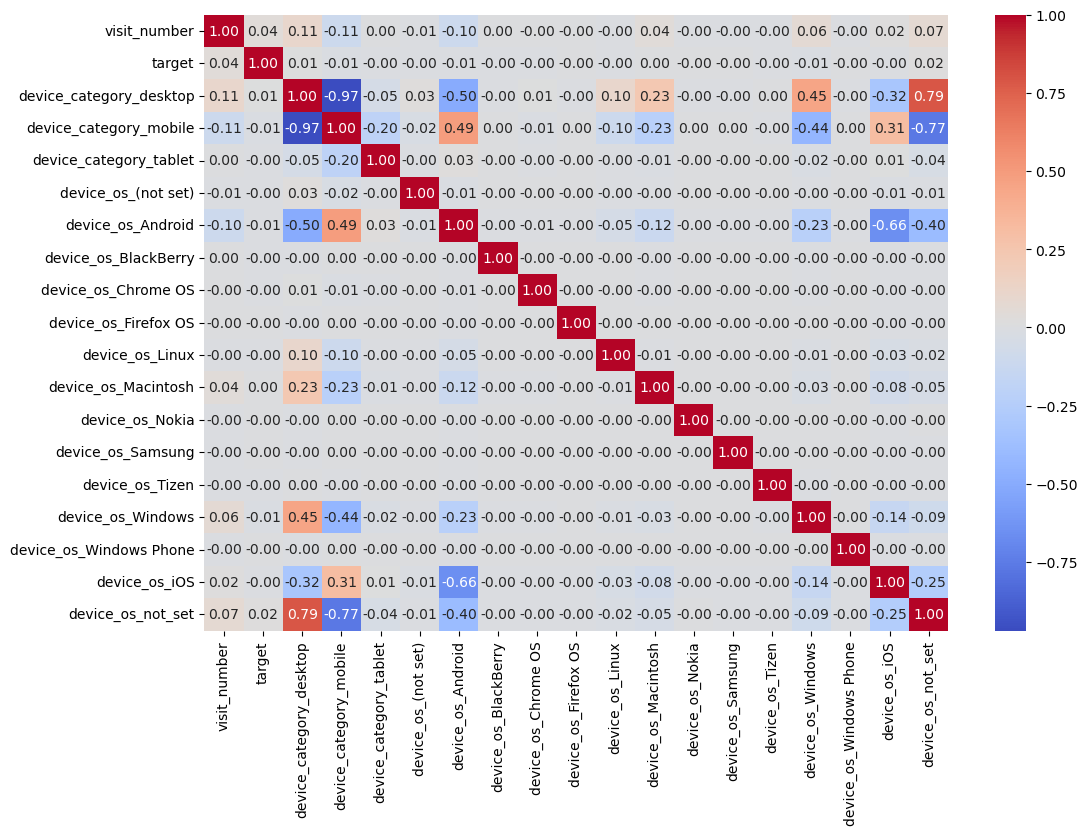

In [72]:
df_corr = pd.get_dummies(X_train[['device_category', 'device_os', 'visit_number']].join(y_train))

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

Корреляция признаков с целевым действием слабая (max ~0.04 у visit_number). Это говорит об отсутствии линейной зависимости, что ожидаемо для задачи предсказания поведения пользователя. Обнаружена сильная мультиколлинеарность между категориями устройств (desktop/mobile: -0.97) и между OS и категорией устройства (iOS/mobile: 0.66), что необходимо учитывать при отборе признаков для модели.

In [74]:
X_train.join(y_train).groupby('device_category')['target'].mean()

device_category
desktop    0.031416
mobile     0.026022
tablet     0.022519
Name: target, dtype: float64

CR по категориям устройств: desktop 3.1%, mobile 2.6%, tablet 2.3%. Категории достаточно различаются, объединение нецелесообразно.

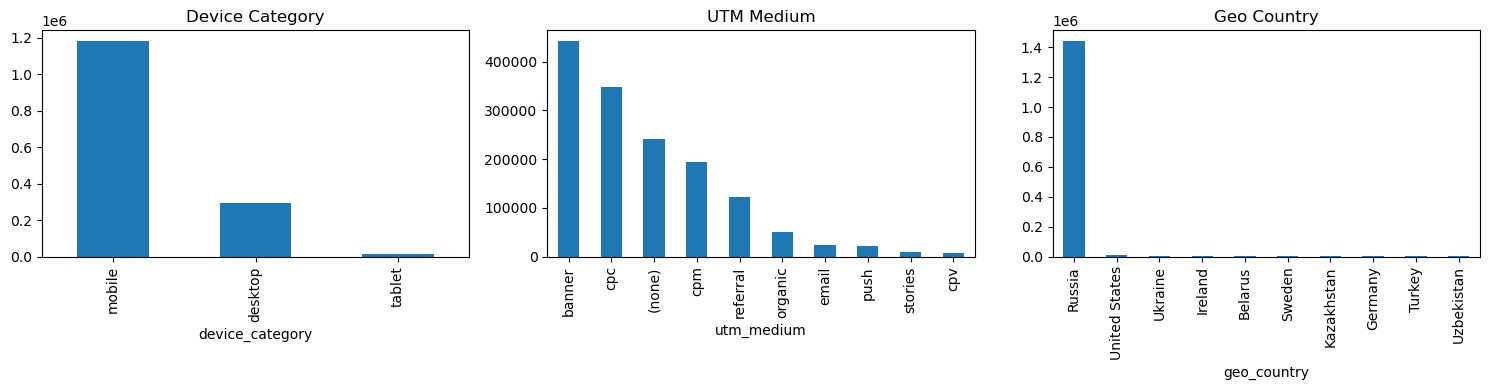

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

X_train['device_category'].value_counts().plot(kind='bar', ax=axes[0], title='Device Category')
X_train['utm_medium'].value_counts().head(10).plot(kind='bar', ax=axes[1], title='UTM Medium')
X_train['geo_country'].value_counts().head(10).plot(kind='bar', ax=axes[2], title='Geo Country')

plt.tight_layout()
plt.show()

Сильно преобладает устройство мобильный телефон.
Компания предпочитает канал привлечения в виде баннера.
География пользователей преимущественно Россия, что логично для российской компании

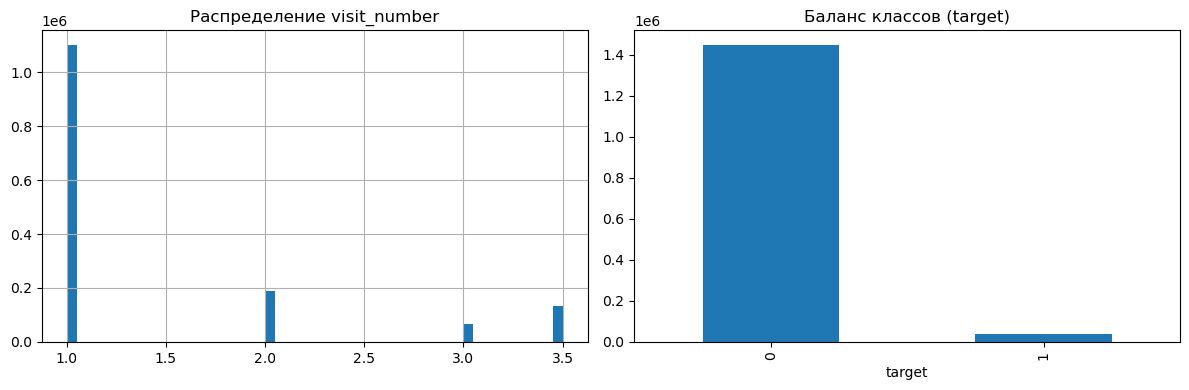

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

X_train['visit_number'].hist(bins=50, ax=axes[0])
axes[0].set_title('Распределение visit_number')

y_train.value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Баланс классов (target)')

plt.tight_layout()
plt.show()

Большинство пользователей новые. Очевидный дизбаланс классов это может плохо сказаться на модели, буду использовать в будущем class_weight='balanced' 

### Feature Engineering

In [78]:
X_train.columns.tolist()

['session_id',
 'client_id',
 'visit_date',
 'visit_time',
 'visit_number',
 'utm_source',
 'utm_medium',
 'utm_campaign',
 'utm_adcontent',
 'utm_keyword',
 'device_category',
 'device_os',
 'device_brand',
 'device_browser',
 'geo_country',
 'geo_city',
 'screen_width',
 'screen_height']

In [79]:
first_visit = X_train.groupby('client_id')['visit_date'].transform('min')
first_visit_map = X_train.groupby('client_id')['visit_date'].min()
X_train['is_new_client'] = (X_train['visit_date'] == first_visit).astype(int)

In [80]:
X_train.is_new_client.unique()

array([1, 0])

In [85]:
X_train['visit_date'].dt.year.value_counts()

visit_date
2021    1488033
Name: count, dtype: int64

In [86]:
X_train['visit_month'] = X_train['visit_date'].dt.month
X_train['visit_day'] = X_train['visit_date'].dt.day
X_train['visit_dayofweek'] = X_train['visit_date'].dt.dayofweek
X_train['visit_hour'] = pd.to_datetime(X_train['visit_time'], format='%H:%M:%S').dt.hour

In [87]:
X_train = X_train.drop(columns=['session_id', 'client_id', 'visit_date', 'visit_time'])

In [88]:
X_train['is_russia'] = (X_train['geo_country'] == 'Russia').astype(int)

X_train['city_group'] = X_train['geo_city'].apply(
    lambda x: 'moscow' if 'Moscow' in str(x) 
    else 'spb' if 'Saint Petersburg' in str(x) 
    else 'other'
)

In [89]:
X_train = X_train.drop(columns=['geo_country', 'geo_city'])

In [90]:
X_train.utm_medium.unique()

array(['email', 'cpm', 'cpc', 'organic', 'banner', '(none)', 'smm',
       'referral', 'push', 'blogger_channel', 'clicks', 'app', 'cpa',
       'blogger_stories', 'smartbanner', 'stories', 'post', 'outlook',
       'tg', 'cpv', 'blogger_header', 'landing', 'sms', 'info_text',
       'fb_smm', 'link', '(not set)', 'vk_smm', 'yandex_cpc', 'cbaafe',
       'static', 'partner', 'promo_sbol', 'CPM', 'article', 'ok_smm',
       'medium', 'nkp', 'desktop', 'web_polka', 'main_polka',
       'google_cpc', 'users_msk', 'social', 'qrcodevideo', 'catalogue',
       'sber_app', 'promo_sber', 'qr', 'tablet', 'linktest', 'dom_click',
       'reach', 'Sbol_catalog', 'landing_interests', 'last'], dtype=object)

In [91]:
organic = ['organic', 'referral', '(none)']
X_train['is_organic'] = X_train['utm_medium'].isin(organic).astype(int)

In [92]:
social_sources = ['QxAxdyPLuQMEcrdZWdWb', 'MvfHsxITijuriZxsqZqt', 
                  'ISrKoXQCxqqYvAZICvjs', 'IZEXUFLARCUMynmHNBGo', 
                  'PlbkrSYoHuZBWfYjYnfw', 'gVRrcxiDQubJiljoTbGm']
X_train['is_social'] = X_train['utm_source'].isin(social_sources).astype(int)

In [94]:
X_train.join(y_train).groupby('is_organic')['target'].mean()

is_organic
0    0.021966
1    0.040301
Name: target, dtype: float64

Органический трафик 4.0% конвертируется лучше чем платный трафик 2,2%

In [95]:
X_train.join(y_train).groupby('is_social')['target'].mean()

is_social
0    0.029215
1    0.014536
Name: target, dtype: float64

Социальные сети ~1.5% конвертируются хуже чем не социальные сети 2.9%

In [96]:
X_train.columns.tolist()

['visit_number',
 'utm_source',
 'utm_medium',
 'utm_campaign',
 'utm_adcontent',
 'utm_keyword',
 'device_category',
 'device_os',
 'device_brand',
 'device_browser',
 'screen_width',
 'screen_height',
 'is_new_client',
 'visit_month',
 'visit_day',
 'visit_dayofweek',
 'visit_hour',
 'is_russia',
 'city_group',
 'is_organic',
 'is_social']

### Подготавливаю данные для OHE

In [97]:
X_train['utm_source'].value_counts(normalize=True).cumsum().head(20)

utm_source
ZpYIoDJMcFzVoPFsHGJL    0.311229
fDLlAcSmythWSCVMvqvL    0.472979
kjsLglQLzykiRbcDiGcD    0.616050
MvfHsxITijuriZxsqZqt    0.716187
BHcvLfOaCWvWTykYqHVe    0.778555
bByPQxmDaMXgpHeypKSM    0.833571
QxAxdyPLuQMEcrdZWdWb    0.861268
aXQzDWsJuGXeBXexNHjc    0.877918
jaSOmLICuBzCFqHfBdRg    0.893583
RmEBuqrriAfAVsLQQmhk    0.908706
vFcAhRxLfOWKhvxjELkx    0.921857
PlbkrSYoHuZBWfYjYnfw    0.933022
hTjLvqNxGggkGnxSCaTm    0.940843
gDBGzjFKYabGgSPZvrDH    0.948097
fgymSoTvjKPEgaIJqsiH    0.953227
ISrKoXQCxqqYvAZICvjs    0.957887
geDcueAOghDzHkGMmdOq    0.962531
nSReTmyFtbSjlPrTKoaX    0.966445
SzZERoLMmrEUEhDaYcyN    0.970114
eLzNJHzPelJpEyBwMrKo    0.972984
Name: proportion, dtype: float64

Топ 20 покрывает 97% значений, делаю вывод что можно оставить только 20 наибольших значений, остальные заменить на other

In [98]:
top_sources = X_train['utm_source'].value_counts().head(20).index
X_train['utm_source'] = X_train['utm_source'].where(X_train['utm_source'].isin(top_sources), other='other')

In [104]:
X_train['utm_campaign'].value_counts(normalize=True).cumsum().head(20)

utm_campaign
LTuZkdKfxRGVceoWkVyg    0.249185
LEoPHuyFvzoNfnzGgfcd    0.423464
FTjNLDyTrXaWYgZymFkV    0.556406
not_set                 0.674288
gecBYcKZCPMcVYdSSzKP    0.746427
TmThBvoCcwkCZZUWACYq    0.760745
okTXSMadDkjvntEHzIjp    0.773951
XHNUiSKKGTEpSAlaVMFQ    0.787071
SgIUDYUKnyWHVowUOqid    0.799379
sbJRYgVfvcnqKJNDDYIr    0.810230
LwJZxKuWmvOhPsaCeRjG    0.819696
RoDitORHdzGfGhNCyEMy    0.828154
bxOTvPtyGSdUrbwoXCPO    0.836442
zxoiLxhuSIFrCeTLQVWZ    0.843081
bJJuEXRheRIxXEaYIXqM    0.849675
YCKgTzTDywjcWyQudGch    0.856111
nSReTmyFtbSjlPrTKoaX    0.862344
QEejXfOCtOMFLZqIPApp    0.867793
vRLTQQKAsFQMxbcHGPhu    0.872866
jvsVVQVKRfBIqBDBuCkq    0.877132
Name: proportion, dtype: float64

In [105]:
top_campaigns = X_train['utm_campaign'].value_counts().head(20).index
X_train['utm_campaign'] = X_train['utm_campaign'].where(X_train['utm_campaign'].isin(top_campaigns), other='other')

In [106]:
X_train['utm_keyword'].value_counts(normalize=True).cumsum().head(20)

utm_keyword
not_set                 0.581650
puhZPIYqKXeFPaUviSjo    0.854333
aXQzDWsJuGXeBXexNHjc    0.867400
pHqgLcdBQPSLcrTpLkdr    0.874826
ITfrGJNwVsHBGJMAKoct    0.881997
hAmNSZmQkKQKAjZEGlgb    0.888048
UKNBOHebRIIsQRsjNKay    0.893897
IGUCNvHlhfHpROGclCit    0.897938
RkpOyeEPgcMBSDuHLQcj    0.901661
JajANoFxoqXfKRNBUhzx    0.905301
BmOOOIoWGHEfxEfoUezs    0.908861
ZNhSIPchlbnKwZWcsKzz    0.911902
pucKZkLDtpMDBTobJAJG    0.914775
RrhnkuoaqckNtJpAZDzH    0.917474
YQXPpoLsxnykCWKhGEmI    0.920085
DBHgBJHOdbPwsRDUbEgX    0.922493
tVtbIKrPSOvrXLCznVVe    0.924463
XEayFbemrPYbxFeNbxif    0.926425
MWLEpQPyjGkjHseVyeyQ    0.928108
fzbotReoFzSuckjwcpCs    0.929711
Name: proportion, dtype: float64

In [108]:
X_train.join(y_train).groupby('utm_keyword').agg(
    count=('target', 'count'),
    cr=('target', 'mean')
).query('count >= 100').sort_values('cr', ascending=False)

,count,cr
utm_keyword,,
UbQpozKfTgYxQovHjkQM,249,0.132530
JTBldRAXvttfVmCNgppl,787,0.128335
mIKayglJaKQZvgdtLfqT,725,0.113103
sKuhgZXGwZSwSoGyRIEH,101,0.079208
aOyuIrXcEKpTEyGVbZFT,408,0.078431
...,...,...
fUhxIMXvMivfzvXbtxXS,101,0.000000
faqsogjxCvbseFqupueU,694,0.000000
iYCvLHKtSHnVUTFbZVoL,491,0.000000


In [109]:
top_keywords = X_train['utm_keyword'].value_counts().head(20).index
X_train['utm_keyword'] = X_train['utm_keyword'].where(X_train['utm_keyword'].isin(top_keywords), other='other')

In [110]:
X_train.columns.tolist()

['visit_number',
 'utm_source',
 'utm_medium',
 'utm_campaign',
 'utm_adcontent',
 'utm_keyword',
 'device_category',
 'device_os',
 'device_brand',
 'device_browser',
 'screen_width',
 'screen_height',
 'is_new_client',
 'visit_month',
 'visit_day',
 'visit_dayofweek',
 'visit_hour',
 'is_russia',
 'city_group',
 'is_organic',
 'is_social']

In [111]:
X_train.select_dtypes('object').nunique().sort_values()

device_category      3
city_group           3
device_os           14
utm_source          21
utm_campaign        21
utm_keyword         21
device_browser      52
utm_medium          56
device_brand       195
utm_adcontent      273
dtype: int64

In [112]:
X_train['utm_adcontent'].value_counts(normalize=True).cumsum().head(20)

utm_adcontent
JNHcPlZPxEMWDnRiyoBf    0.541273
not_set                 0.721495
vCIpmpaGBnIQhyYNkXqp    0.818966
xhoenQgDQsgfEPYNPwKO    0.879723
PkybGvWbaqORmxjNunqZ    0.912257
LLfCasrxQzJIyuldcuWy    0.925312
TuyPWsGQruPMpKvRxeBF    0.935096
UxrnyMlRBSOhOjytXnMG    0.942358
dUuXlWzvmhDSyclWRhNP    0.947867
yYdBRbPmBMUZHXwqGxNx    0.953039
WYLajZgbUhGimwBKDZUH    0.957647
SOkCdPxfUcZUzzOdgGES    0.961630
AdeErYgVTbRcAWtHrMHq    0.965034
nNqUcgFgcqQbTVSvgaHr    0.968335
aYAcKhelKzYpXrRYknSP    0.971038
XSkXBCPfnJjvxbfeewtd    0.973390
XKsYZiUFcdkUXQpoLKyS    0.975593
FkiRXDLOWtzVfvhEkhNo    0.977126
xnyHaukLtAvgViiZSyBC    0.978521
SAVVWaMghGnnvPOqMOIt    0.979882
Name: proportion, dtype: float64

In [113]:
top_adcontent = X_train['utm_adcontent'].value_counts().head(20).index
X_train['utm_adcontent'] = X_train['utm_adcontent'].where(X_train['utm_adcontent'].isin(top_adcontent), other='other')

In [114]:
X_train['device_brand'].value_counts(normalize=True).cumsum().head(20)

device_brand
Apple        0.296568
not_set      0.493615
Samsung      0.672264
Xiaomi       0.827589
Huawei       0.927369
Realme       0.937571
(not set)    0.947008
OPPO         0.954225
Vivo         0.960580
OnePlus      0.965958
Asus         0.970183
Nokia        0.974067
Sony         0.977533
ZTE          0.980936
Google       0.983730
Meizu        0.985760
Lenovo       0.987438
Blackview    0.988899
Tecno        0.990334
LG           0.991667
Name: proportion, dtype: float64

In [115]:
top_brands = X_train['device_brand'].value_counts().head(20).index
X_train['device_brand'] = X_train['device_brand'].where(X_train['device_brand'].isin(top_brands), other='other')

In [116]:
X_train['utm_medium'].value_counts(normalize=True).cumsum().head(20)

utm_medium
banner             0.297145
cpc                0.530746
(none)             0.692495
cpm                0.822489
referral           0.904132
organic            0.938018
email              0.953682
push               0.968780
stories            0.974460
cpv                0.978803
blogger_channel    0.983080
smartbanner        0.986779
blogger_stories    0.989129
cpa                0.991449
tg                 0.993588
app                0.995118
post               0.996370
smm                0.997446
outlook            0.998146
clicks             0.998655
Name: proportion, dtype: float64

In [117]:
top_medium = X_train['utm_medium'].value_counts().head(20).index
X_train['utm_medium'] = X_train['utm_medium'].where(X_train['utm_medium'].isin(top_medium), other='other')

In [118]:
X_train['device_browser'].value_counts(normalize=True).cumsum().head(20)

device_browser
Chrome                              0.544759
Safari                              0.802182
YaBrowser                           0.873804
Safari (in-app)                     0.911369
Android Webview                     0.941237
Samsung Internet                    0.966730
Opera                               0.981134
Firefox                             0.989979
Edge                                0.998565
UC Browser                          0.999042
Android Runtime                     0.999256
Mozilla Compatible Agent            0.999446
[FBAN                               0.999591
Instagram 208.0.0.32.135 Android    0.999663
Instagram 209.0.0.21.119 Android    0.999721
MRCHROME                            0.999761
Opera Mini                          0.999786
Android Browser                     0.999810
Puffin                              0.999833
Internet Explorer                   0.999853
Name: proportion, dtype: float64

In [119]:
top_browsers = X_train['device_browser'].value_counts().head(20).index
X_train['device_browser'] = X_train['device_browser'].where(X_train['device_browser'].isin(top_browsers), other='other')

In [120]:
X_train.select_dtypes('object').nunique().sort_values()

device_category     3
city_group          3
device_os          14
utm_source         21
utm_medium         21
utm_campaign       21
utm_adcontent      21
utm_keyword        21
device_brand       21
device_browser     21
dtype: int64

### Подготовавливаю x_test

In [123]:
X_test_processed = transform(X_test, artifacts)

# Пересчитываем колонки после transform
cat_cols = X_train.select_dtypes('object').columns.tolist()
num_cols = X_train.select_dtypes('number').columns.tolist()

# Save Prepared DS

In [121]:
X_train.to_csv('data/df_prepared.csv', index=False)

In [122]:
X_train.columns.tolist()

['visit_number',
 'utm_source',
 'utm_medium',
 'utm_campaign',
 'utm_adcontent',
 'utm_keyword',
 'device_category',
 'device_os',
 'device_brand',
 'device_browser',
 'screen_width',
 'screen_height',
 'is_new_client',
 'visit_month',
 'visit_day',
 'visit_dayofweek',
 'visit_hour',
 'is_russia',
 'city_group',
 'is_organic',
 'is_social']

# Modeling

Использую ROC-AUC как метрику качества потому что 
1. Класси сильно несбалансированы, только 3% единиц
2. Accuracy бесполезно т.к. модель предсказывающая всегда 0 дает 97% точности
3. ROC-AUC оценивает способность модели ранжировать положительные ответы выше отрицательных

In [126]:
param_grids = {
    'LogisticRegression': {
        'model__C': [0.01, 0.1, 1, 10],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None],
        'model__min_samples_leaf': [1, 5]
    },
    'MLP': {
        'model__hidden_layer_sizes': [(64, 32), (128, 64), (256, 128, 64)],
        'model__alpha': [0.0001, 0.001]
    }
}

In [127]:
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=0.05, random_state=42, stratify=y_train
)

In [129]:
models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'MLP': MLPClassifier(random_state=42, max_iter=500)
}

In [130]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

In [131]:
best_pipe = None
best_score = 0.0

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    grid_search = GridSearchCV(
        pipe,
        param_grids[name],
        scoring='roc_auc',
        cv=3,
        n_jobs=-1
    )
    
    grid_search.fit(X_sample, y_sample)
    
    y_pred = grid_search.best_estimator_.predict_proba(X_test_processed)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    print(f'{name}: ROC-AUC = {auc:.4f}, лучшие параметры: {grid_search.best_params_}')
    
    if auc > best_score:
        best_score = auc
        best_pipe = grid_search.best_estimator_

LogisticRegression: ROC-AUC = 0.6481, лучшие параметры: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
RandomForest: ROC-AUC = 0.6556, лучшие параметры: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
MLP: ROC-AUC = 0.5314, лучшие параметры: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64, 32)}


Лучше всего показала себя модель Random forest, буду использовать ее.

In [132]:
final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        max_depth=10,
        min_samples_leaf=5,
        n_estimators=200
    ))
])

# Обучаем на всех тренировочных данных
final_pipe.fit(X_train, y_train)

# Финальная оценка
y_pred = final_pipe.predict_proba(X_test_processed)[:, 1]
print(f'Final ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}')

Final ROC-AUC: 0.6859


In [133]:
X_train.columns

Index(['visit_number', 'utm_source', 'utm_medium', 'utm_campaign',
       'utm_adcontent', 'utm_keyword', 'device_category', 'device_os',
       'device_brand', 'device_browser', 'screen_width', 'screen_height',
       'is_new_client', 'visit_month', 'visit_day', 'visit_dayofweek',
       'visit_hour', 'is_russia', 'city_group', 'is_organic', 'is_social'],
      dtype='object')

In [134]:
X_test_processed.columns

Index(['visit_number', 'utm_source', 'utm_medium', 'utm_campaign',
       'utm_adcontent', 'utm_keyword', 'device_category', 'device_os',
       'device_brand', 'device_browser', 'visit_month', 'visit_day',
       'visit_dayofweek', 'visit_hour', 'is_russia', 'is_new_client',
       'city_group', 'is_organic', 'is_social', 'screen_width',
       'screen_height'],
      dtype='object')

In [135]:
X_test_processed = X_test_processed[X_train.columns]

X_all = pd.concat([X_train, X_test_processed])
y_all = pd.concat([y_train, y_test])

final_pipe.fit(X_all, y_all)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [136]:
artifacts['model'] = final_pipe

In [137]:
with open('model/sber_auto_model.pkl', 'wb') as f:
    dill.dump(artifacts, f)

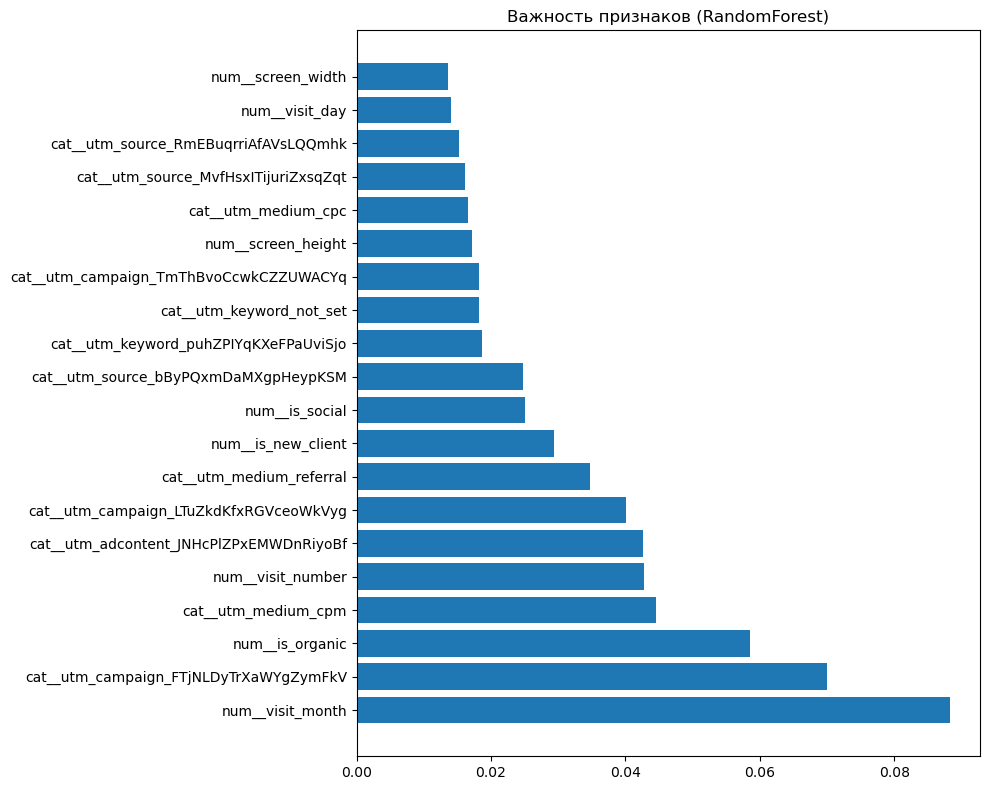

In [139]:
feature_names = final_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = final_pipe.named_steps['model'].feature_importances_

feat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feat_importance['feature'], feat_importance['importance'])
plt.title('Важность признаков (RandomForest)')
plt.tight_layout()
plt.show()

несмотря на то что названия зашифрованы, конкретные источники и рекламные материалы сильно влияют на вероятность целевого действия. Это говорит о том что качество рекламного контента важнее канала привлечения.

In [140]:
dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])
dummy.fit(X_train, y_train)
y_dummy = dummy.predict_proba(X_test_processed)[:, 1]
print(f'Baseline ROC-AUC: {roc_auc_score(y_test, y_dummy):.4f}')
print(f'RandomForest ROC-AUC: {best_score:.4f}')

Baseline ROC-AUC: 0.5000
RandomForest ROC-AUC: 0.6556


Логистическая регрессия показала ROC-AUC = 0.6556 против бейслайна 0.50, превысив цель в 0.65. Модель сильно лучше случайного предсказания.